# 🛒 DecodeLabs Data Analytics Project

## Objective

The objective of this project is to perform data cleaning, exploratory data analysis (EDA), visualization, and generate business insights from an e-commerce dataset provided by DecodeLabs.

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

# Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside notebook
%matplotlib inline

# Better looking plots
plt.style.use("ggplot")

# Step 2: Load the Dataset

In [2]:
df = pd.read_excel("../data/dataset.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Step 3: Initial Data Inspection


In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (1200, 14)

Column Names:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNu

In [4]:
df.describe(include="all")

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,NaN,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD200000,NaN,C98474,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK37947903,NaN,FREESHIP,Instagram,NaN
freq,1,NaN,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,2024-03-22 16:58:48,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
min,NaN,2023-01-01 00:00:00,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,2023-08-03 18:00:00,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,2024-03-23 00:00:00,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,2024-11-08 12:00:00,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000
max,NaN,2025-06-30 00:00:00,NaN,NaN,5.000000,699.930000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,3456.400000


In [5]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

# Step 4: Data Quality Assessment

In [6]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [7]:
duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


In [8]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].nunique())


OrderID
1200

Date
671

CustomerID
1189

Product
7

Quantity
5

UnitPrice
1193

ShippingAddress
655

PaymentMethod
5

OrderStatus
5

TrackingNumber
1200

ItemsInCart
10

CouponCode
3

ReferralSource
5

TotalPrice
1195


In [9]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

# Step 5: Missing Value Treatment

The dataset contains missing values only in the `CouponCode` column. Since this is a categorical feature, numerical imputation techniques such as Mean or Median are not applicable.

A missing coupon code most likely indicates that no coupon was applied during the purchase. Therefore, the missing values are replaced with **"No Coupon"**.

In [10]:
# Fill missing coupon codes
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

# Verify
df["CouponCode"].isnull().sum()

np.int64(0)

# Step 6: Outlier Detection

In [11]:
numeric_columns = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

df[numeric_columns].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


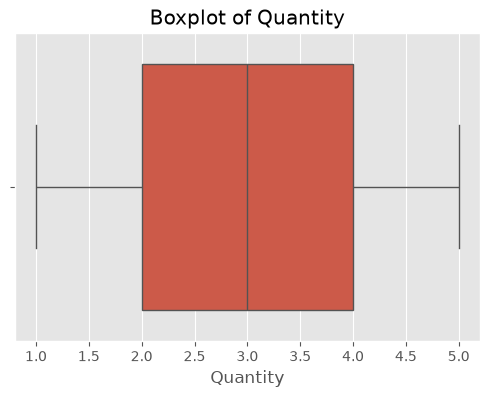

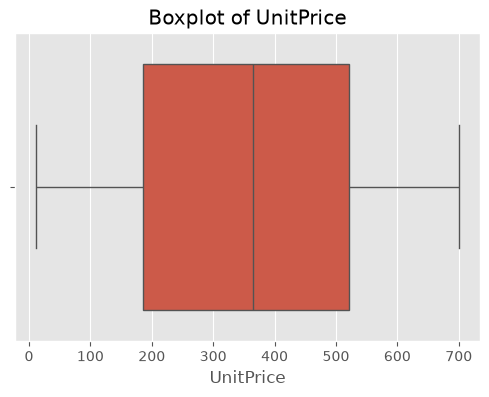

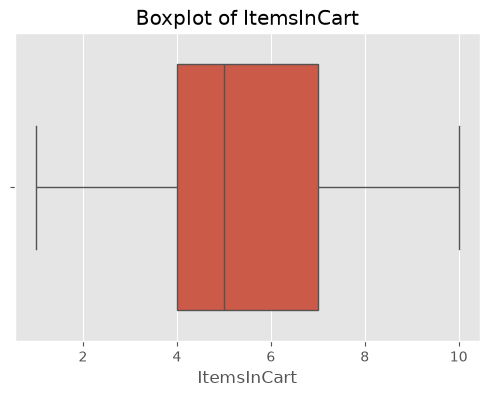

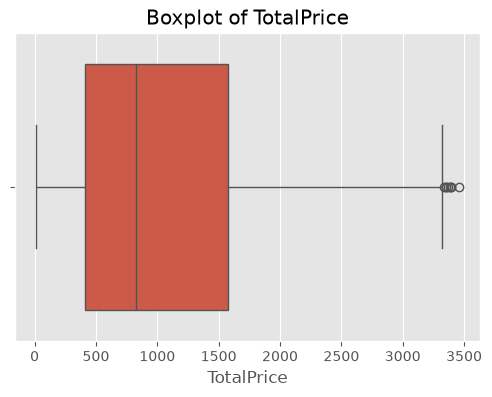

In [12]:
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [13]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 8 outliers


# Step 6: Outlier Detection

Outliers are unusually high or low values that may affect statistical analysis and model performance. We will identify outliers using the Interquartile Range (IQR) method and visualize them using boxplots.

In [14]:
numeric_columns = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

df[numeric_columns].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


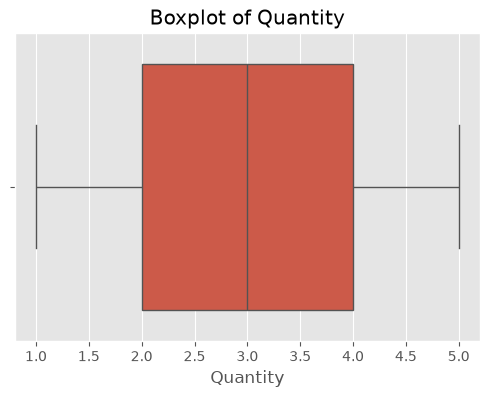

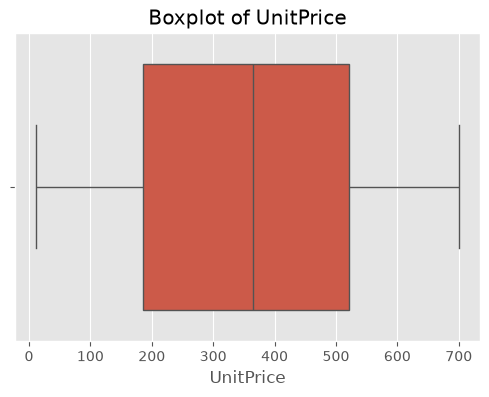

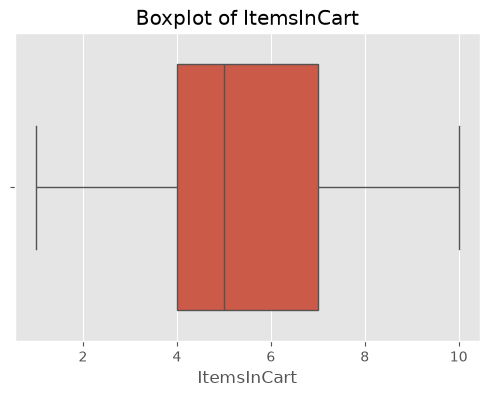

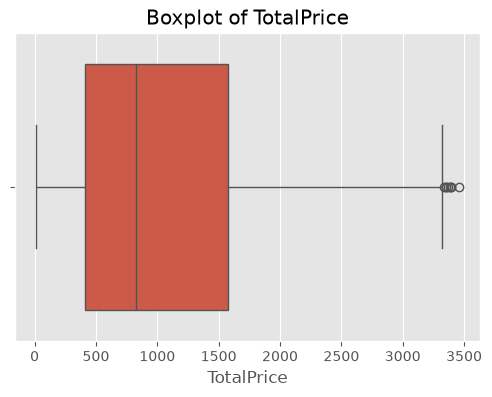

In [15]:
for column in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [16]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 8 outliers


## Outlier Analysis

The IQR method was used to detect outliers in the numerical columns.

### Findings

- Quantity: No outliers detected.
- UnitPrice: No outliers detected.
- ItemsInCart: No outliers detected.
- TotalPrice: 8 outliers detected.

Since only a small number of outliers were found in `TotalPrice`, they are retained because they may represent genuine high-value customer purchases rather than data entry errors.

# Step 7: Feature Engineering

Feature engineering creates new variables from existing data to uncover additional insights and improve analysis.

In [17]:
df["CouponUsed"] = df["CouponCode"].apply(
    lambda x: "Yes" if x != "No Coupon" else "No"
)

In [18]:
df["OrderValueCategory"] = pd.cut(
    df["TotalPrice"],
    bins=[0, 500, 1500, float("inf")],
    labels=["Low", "Medium", "High"]
)

In [19]:
df["AveragePricePerItem"] = df["TotalPrice"] / df["Quantity"]

In [20]:
df["CartEfficiency"] = df["TotalPrice"] / df["ItemsInCart"]

In [21]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CouponUsed,OrderValueCategory,AveragePricePerItem,CartEfficiency
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,Yes,High,570.62,407.585714
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,Yes,Low,151.35,100.900000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,Yes,High,550.68,344.175000
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,Yes,Low,273.19,54.638000
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,Yes,High,626.01,313.005000


## Visualization 1: Product Distribution

This chart shows the number of orders for each product category.

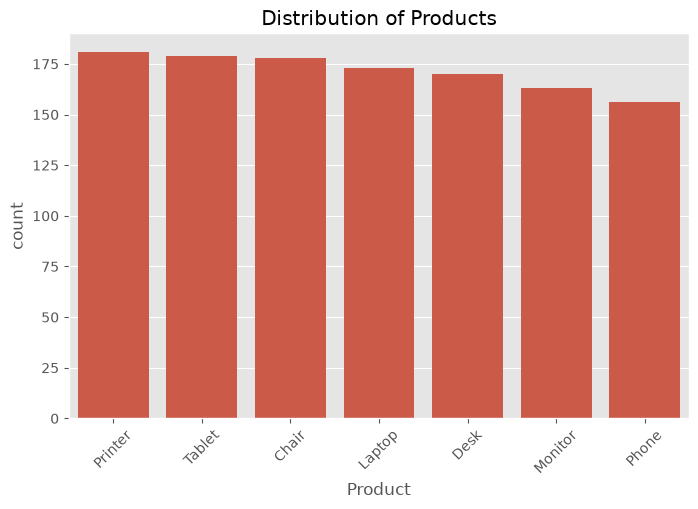

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Product", order=df["Product"].value_counts().index)
plt.title("Distribution of Products")
plt.xticks(rotation=45)
plt.show()

**Insight:**
This visualization helps identify the most frequently ordered products, enabling businesses to understand customer preferences and inventory demand.

## Visualization 2: Order Status Distribution

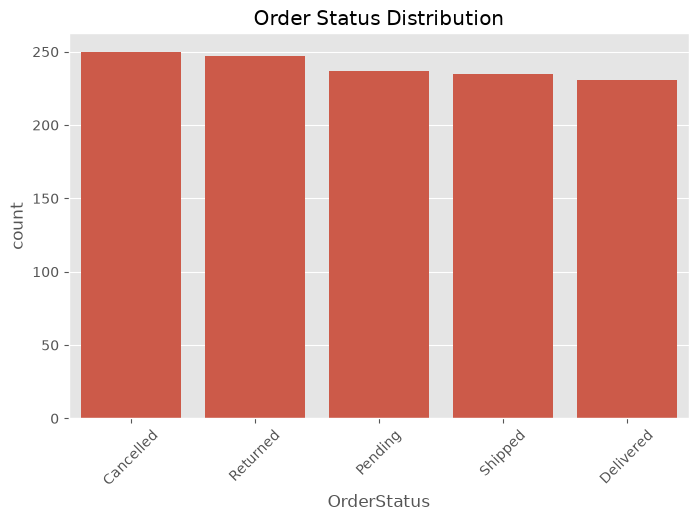

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="OrderStatus", order=df["OrderStatus"].value_counts().index)
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

The distribution of order statuses helps evaluate the efficiency of order fulfillment and identify the proportion of cancelled or returned orders.

## Visualization 3: Payment Method Distribution

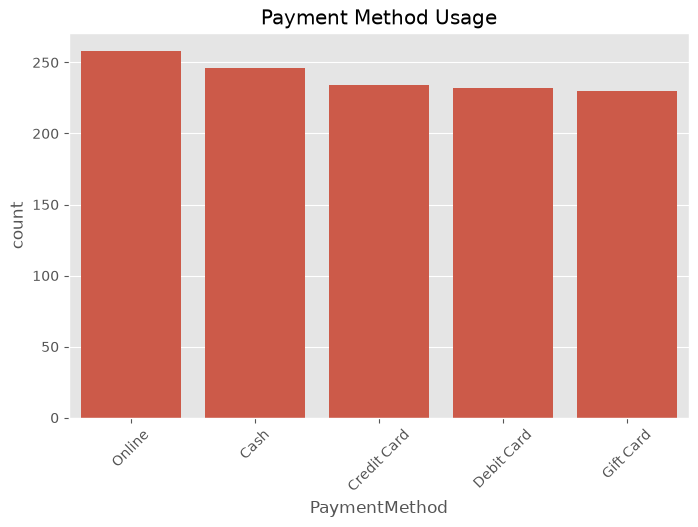

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="PaymentMethod", order=df["PaymentMethod"].value_counts().index)
plt.title("Payment Method Usage")
plt.xticks(rotation=45)
plt.show()

Understanding preferred payment methods helps businesses optimize payment options and improve customer convenience.

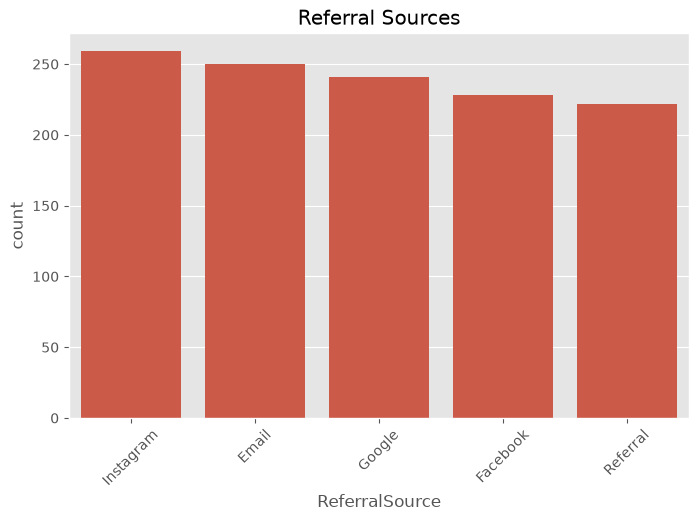

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="ReferralSource", order=df["ReferralSource"].value_counts().index)
plt.title("Referral Sources")
plt.xticks(rotation=45)
plt.show()

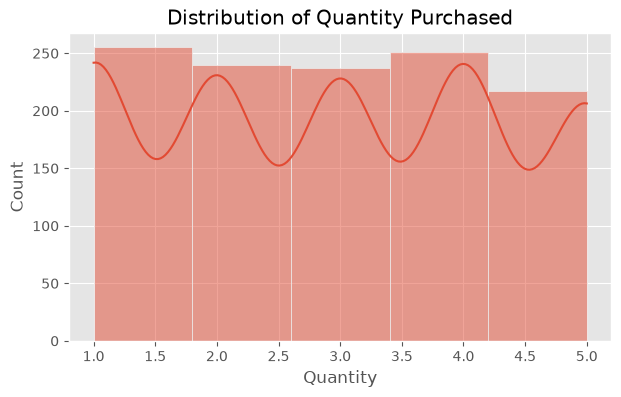

In [27]:
plt.figure(figsize=(7,4))
sns.histplot(df["Quantity"], bins=5, kde=True)
plt.title("Distribution of Quantity Purchased")
plt.show()

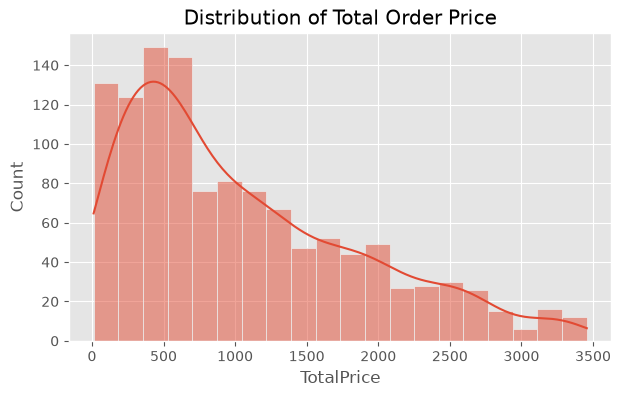

In [28]:
plt.figure(figsize=(7,4))
sns.histplot(df["TotalPrice"], bins=20, kde=True)
plt.title("Distribution of Total Order Price")
plt.show()

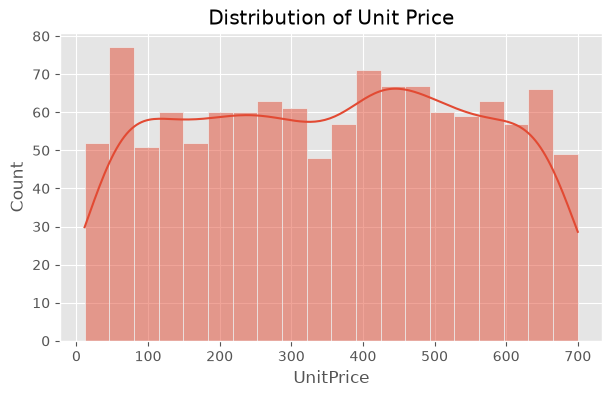

In [29]:
plt.figure(figsize=(7,4))
sns.histplot(df["UnitPrice"], bins=20, kde=True)
plt.title("Distribution of Unit Price")
plt.show()

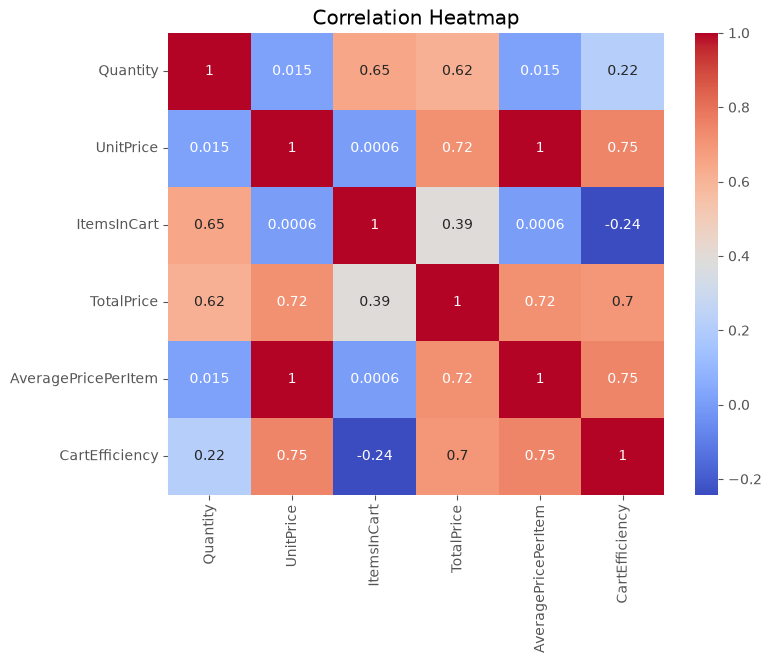

In [30]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

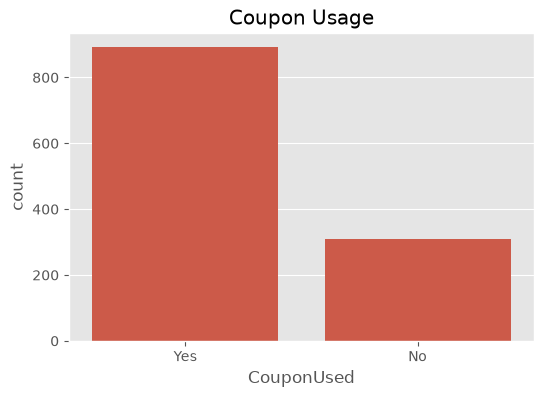

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="CouponUsed")
plt.title("Coupon Usage")
plt.show()

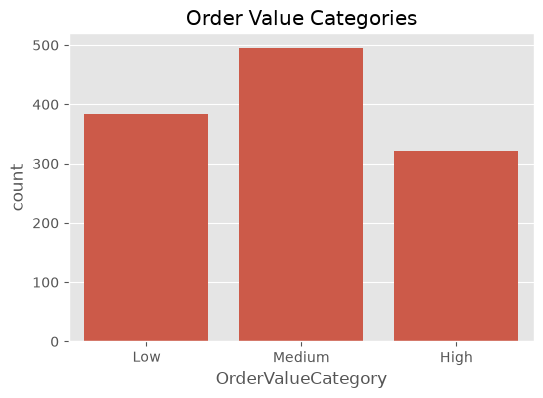

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="OrderValueCategory")
plt.title("Order Value Categories")
plt.show()

# Business Insights

1. Identify the most popular product category.
2. Determine the most frequently used payment method.
3. Evaluate customer coupon usage.
4. Analyze the most common referral source.
5. Assess the distribution of order values.
6. Observe customer purchasing patterns.
7. Identify relationships among numerical variables using the correlation heatmap.
8. Review order fulfillment performance through order status analysis.

In [33]:
df.to_csv("../cleaned_data/cleaned_dataset.csv", index=False)

## Project Preview

![Product Distribution](images/product_distribution.png)

![Correlation Heatmap](images/correlation_heatmap.png)